In [1]:
import pandas as pd

In [2]:
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv(r"/content/diabetes.csv")

In [8]:
cols = list(df.columns)
print(cols)

['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi', 'pedigree', 'age', 'label']


In [9]:
lbl = 'label'

In [10]:
# create decission tree classifier object
from sklearn.tree import DecisionTreeClassifier

In [11]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

In [12]:
df.head()

,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
cols.remove(lbl)
feature_cols=cols
print(feature_cols)


['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi', 'pedigree', 'age']


In [14]:
X = df[feature_cols] # Features
y = df[lbl] # Target varible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state  = 1)

In [15]:
# Train classifer
clf = clf.fit(X_train, y_train)
# predict the response for test dataset
y_pred = clf. predict(X_test)

In [16]:
# calculate accuracy
from sklearn import metrics

In [17]:
result = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(result)

Confusion Matrix:
[[124  22]
 [ 31  54]]


In [18]:
# [row, column]
TP = result[1,1]
TN = result[0,0]
FP = result[0,1]
FN = result[1,0]

In [ ]:
print("Accuracy:\t",metrics.accuracy_score(y_test, y_pred))
print("Sensitivity:\t",metrics.recall_score(y_test, y_pred))
print("Specificity:\t",TN / (TN + FP))
print("Precision:\t",metrics.precision_score(y_test, y_pred))
print("Classification Eerror:", 1 - metrics.accuracy_score(y_test, y_pred))
print("False_Positive_Rate:",1 - TN / (TN + FP))

Accuracy:	 0.7705627705627706
Sensitivity:	 0.6352941176470588
Specificity:	 0.8493150684931506
Precision:	 0.7105263157894737
Classification Eerror: 0.22943722943722944
False_Positive_Rate: 0.15068493150684936


In [19]:
y = pd.DataFrame({'Original': y_test, 'Predicted': y_pred})

y.head()

,Original,Predicted
285,0,0
101,0,0
581,0,0
352,0,0
726,0,0


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

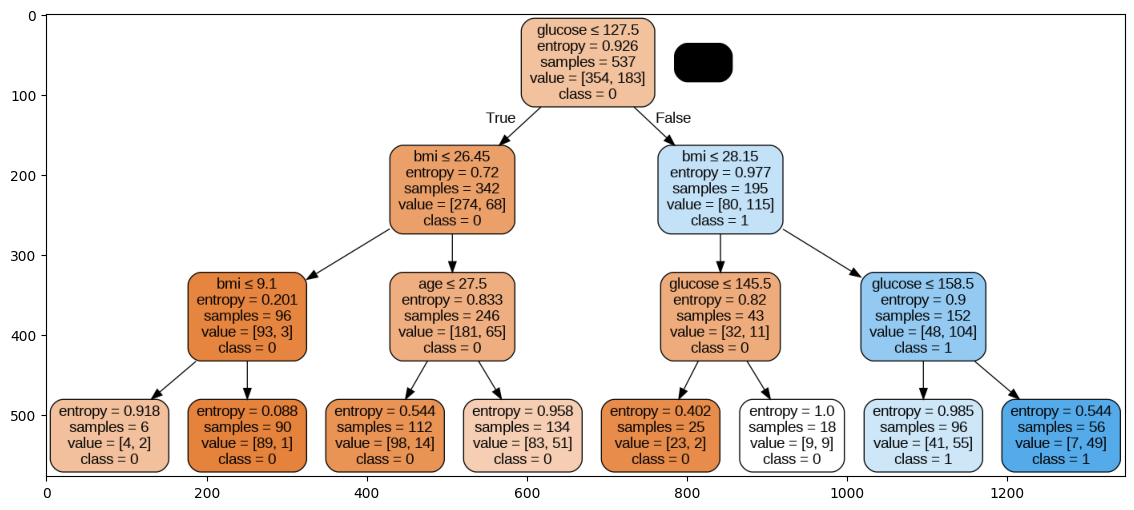

In [20]:
imgFile = 'DecTree.png'
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data, filled=True, rounded=True, special_characters=True, feature_names = feature_cols, class_names=['0','1'])
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png(imgFile)
Image(graph.create_png())
img = mpimg.imread(imgFile)
plt.figure(figsize = (20,6))
plt.imshow(img)

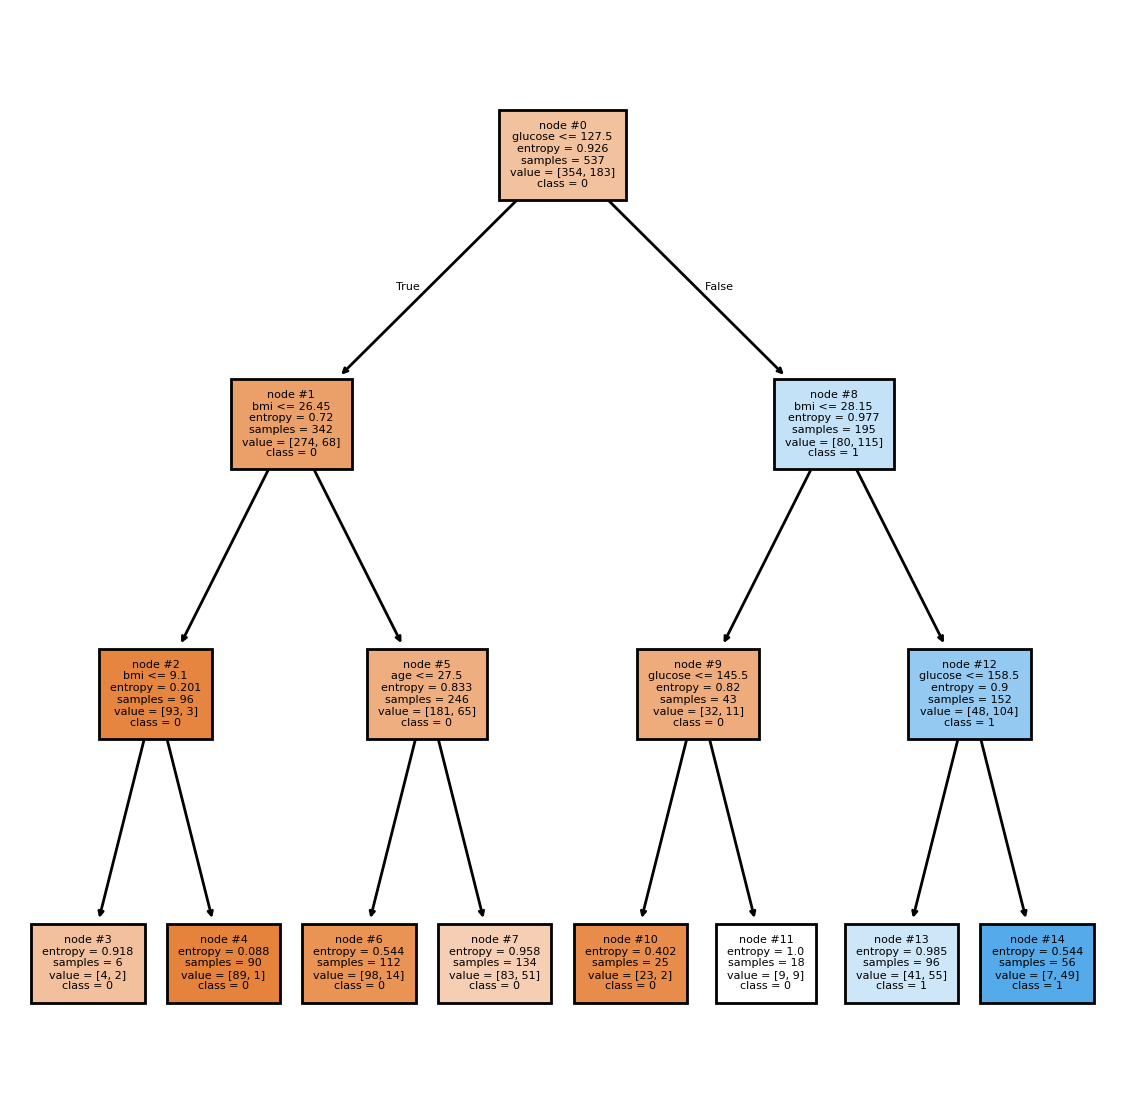

In [ ]:
from sklearn import tree

# Plot the decision tree with customizations
plt.figure(figsize=(7, 7), dpi=200)
plt.title("Decision Tree Visualization")
tree.plot_tree(clf, filled=True, feature_names=list(X_train.columns), class_names=['0','1'],
                                   fontsize=4, max_depth=4, node_ids=True)

plt.show()